In [5]:
from spin_lattices import SpinLattice, KagomeLattice, SquareLattice, TriangularLattice
from heisenberg_hamiltonians import HeisenbergJ1J2, SpinSystem
import numpy as np
import numpy.typing as npt
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import itertools
from misc_utils import hadamard_transform_pytorch_inplace
import torch
import unittest
from tqdm.auto import tqdm
from fourier_supervised_cleanroom_2023_09_27 import (
    get_config,
    output_dir,
    default_config
)
from misc_utils import read_jsonl_to_df, keep_serializable, column_to

In [6]:
df = read_jsonl_to_df(output_dir.glob("*/results.jsonl")).fillna(keep_serializable(default_config))

In [3]:
(df.loc[
    df.query('lattice == "kagome2x4" and eps_train == 0.01')
    .groupby(["J2"])["accuracy"]
    .idxmax()
])

,n_test,lattice,keep_terms,accuracy,overlap,weight_kept,eps_train,J2,n_spins,task_id,sampling_power_train
1215,50000,kagome2x4,2,1.00000,1.000000,0.003224,0.01,0.0,24,11,4.00
1284,50000,kagome2x4,2,1.00000,1.000000,0.003224,0.01,0.1,24,11,4.00
1353,50000,kagome2x4,2,1.00000,1.000000,0.003224,0.01,0.2,24,11,4.00
4689,50000,kagome2x4,2,0.98932,1.000000,0.003090,0.01,0.3,24,10,0.01
4763,50000,kagome2x4,64,0.97384,0.999994,0.003239,0.01,0.4,24,10,0.01
2319,50000,kagome2x4,2,0.94644,0.999970,0.003214,0.01,0.5,24,8,1.00
2401,50000,kagome2x4,16384,0.68008,0.989120,0.056709,0.01,0.6,24,8,1.00
2470,50000,kagome2x4,16384,0.66590,0.987915,0.056083,0.01,0.7,24,8,1.00
2540,50000,kagome2x4,32768,0.66134,0.991191,0.069109,0.01,0.8,24,8,1.00
2609,50000,kagome2x4,32768,0.65200,0.991391,0.072480,0.01,0.9,24,8,1.00


In [16]:
# sns.relplot(
#     df.melt(
#         id_vars=["J2", "lattice", "eps_train", "sampling_power_train", "keep_terms"],
#         value_vars=["overlap", "accuracy"],
#     ).query('lattice == "kagome2x4" and eps_train == 0.01'),
#     col="J2",
#     y="value",
#     hue="variable",
#     x="sampling_power_train",
#     kind='line',
#     row='keep_terms',
#     markers=['o'],
#     dashes=False,
#     style="variable",
# )

/tmp/nix-shell.zxkIYm/ipykernel_1763430/399947743.py:1: UserWarning: 
The markers list has fewer values (1) than needed (2) and will cycle, which may produce an uninterpretable plot.
  sns.relplot(
/nix/store/525hx0cz3k0s2nya7r7rai9s4rr5q4kd-python3-3.10.12-env/lib/python3.10/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


/nix/store/525hx0cz3k0s2nya7r7rai9s4rr5q4kd-python3-3.10.12-env/lib/python3.10/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


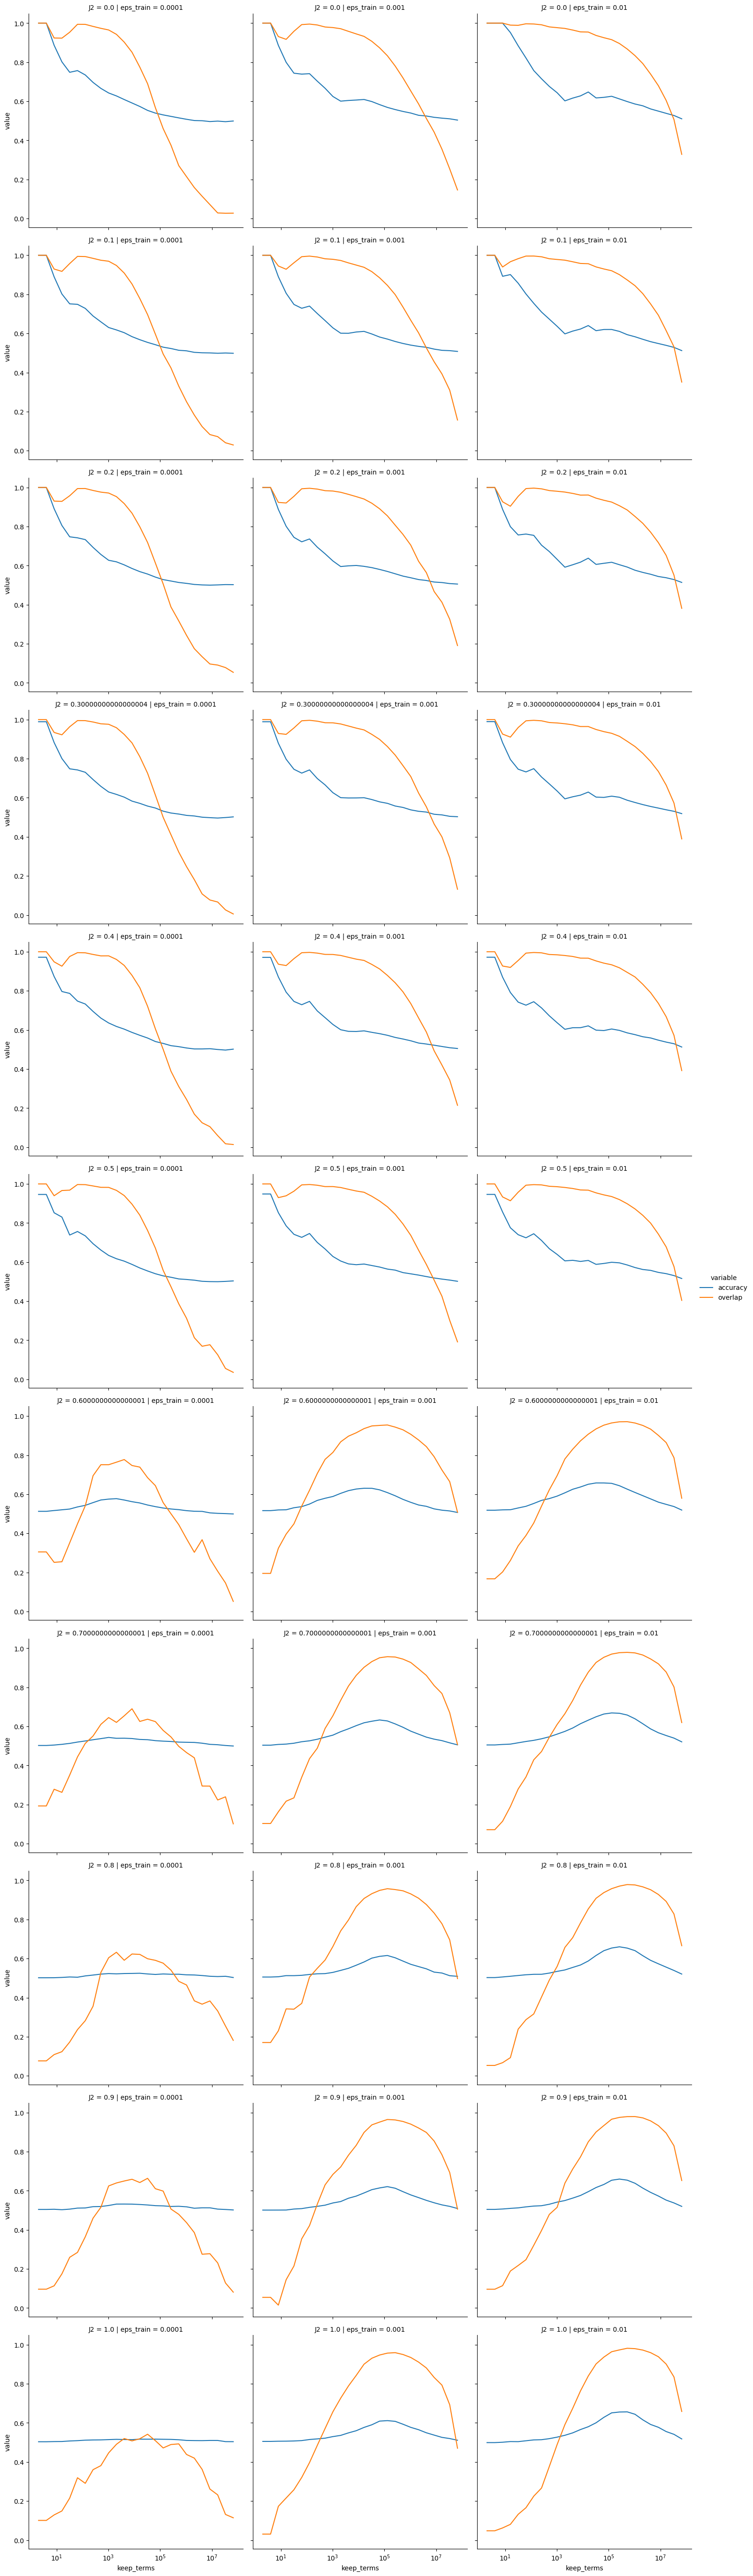

In [5]:
sns.relplot(
    df.query('lattice=="kagome3x3"').melt(
        id_vars=["keep_terms", "eps_train", "weight_kept", "lattice", "J2"],
        value_vars=["accuracy", "overlap", "weight_kept"],
    ),
    x="keep_terms",
    y="value",
    hue="variable",
    col="eps_train",
    row="J2",
    kind="line",
).set(xscale="log")

/nix/store/525hx0cz3k0s2nya7r7rai9s4rr5q4kd-python3-3.10.12-env/lib/python3.10/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


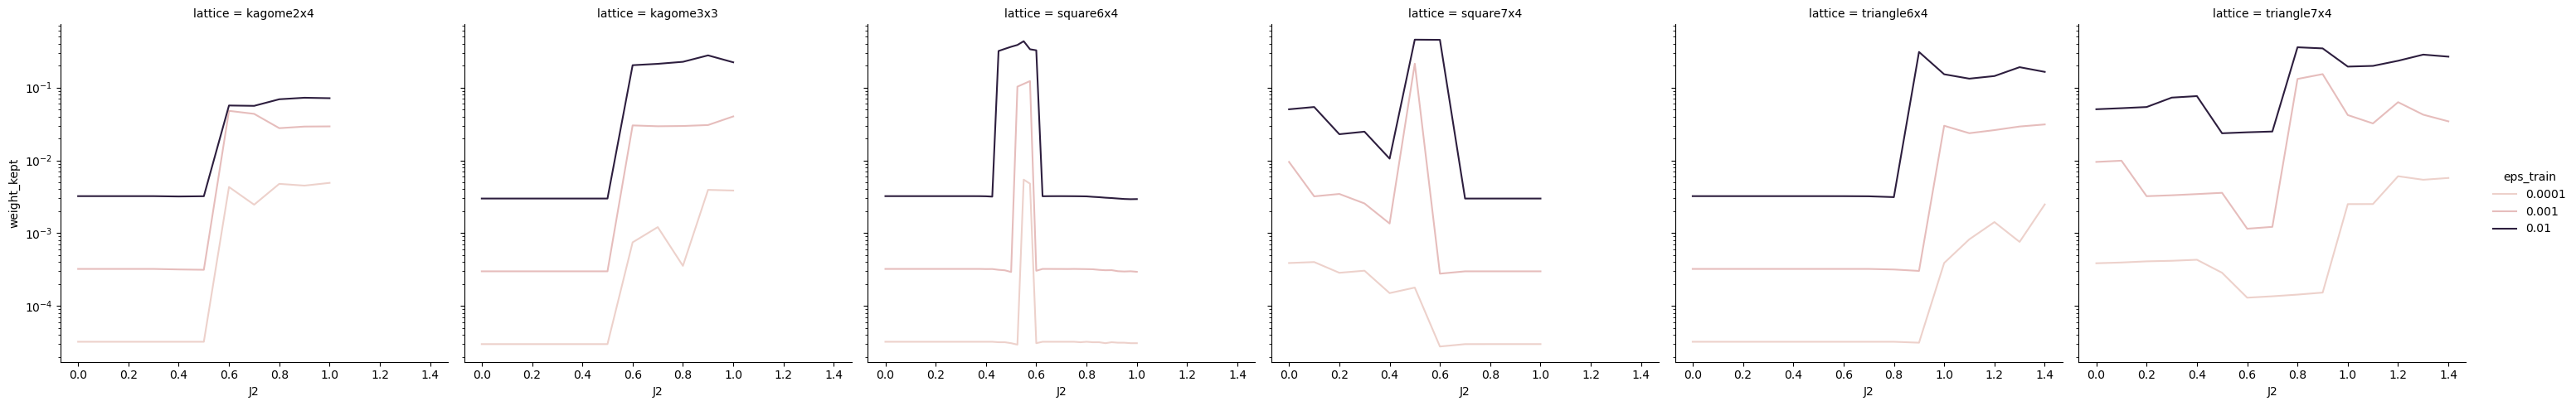

In [4]:
sns.relplot(
    df.loc[df.groupby(['lattice', 'eps_train', 'J2'])['overlap'].idxmax().reset_index(drop=True)],
    x='J2',
    y='weight_kept',
    hue='eps_train',
    col='lattice',
    kind='line',
).set(yscale='log')

In [76]:
df.sort_values('accuracy', ascending=False).head(10)

,keep,accuracy,overlap,weight_kept,eps_train
0,2,0.9987,0.620463,0.000323,0.01
1,4,0.9987,0.620463,0.000352,0.01
2,8,0.9987,0.620463,0.000409,0.01
3,16,0.9263,0.647483,0.000518,0.01
4,32,0.8591,0.538986,0.000715,0.01
5,64,0.7899,0.594330,0.001068,0.01
6,128,0.7217,0.441609,0.001706,0.01
7,256,0.6553,0.585726,0.002684,0.01
8,512,0.6247,0.499010,0.004165,0.01
9,1024,0.6116,0.491321,0.006605,0.01


In [7]:
df.columns

Index(['n_test', 'lattice', 'keep_terms', 'accuracy', 'overlap', 'weight_kept',
       'eps_train', 'J2', 'n_spins', 'task_id', 'sampling_power_train'],
      dtype='object')

In [10]:
df

,n_test,lattice,keep_terms,accuracy,overlap,weight_kept,eps_train,J2,n_spins,task_id,sampling_power_train
0,50000,triangle7x4,2,0.55340,0.521551,0.000951,0.0100,0.0,28,5,2.0
1,50000,triangle7x4,4,0.55340,0.521551,0.001902,0.0100,0.0,28,5,2.0
2,50000,triangle7x4,8,0.58012,0.765537,0.003797,0.0100,0.0,28,5,2.0
3,50000,triangle7x4,16,0.63680,0.946621,0.006968,0.0100,0.0,28,5,2.0
4,50000,triangle7x4,32,0.62796,0.935854,0.009606,0.0100,0.0,28,5,2.0
...,...,...,...,...,...,...,...,...,...,...,...
10618,50000,kagome2x4,524288,0.50588,0.257952,0.200314,0.0001,1.0,24,0,2.0
10619,50000,kagome2x4,1048576,0.50572,0.232778,0.324711,0.0001,1.0,24,0,2.0
10620,50000,kagome2x4,2097152,0.50138,0.192712,0.502598,0.0001,1.0,24,0,2.0
10621,50000,kagome2x4,4194304,0.50388,0.169924,0.723918,0.0001,1.0,24,0,2.0


/tmp/nix-shell.zW0Zbq/ipykernel_2892212/739468236.py:1: UserWarning: 
The markers list has fewer values (1) than needed (3) and will cycle, which may produce an uninterpretable plot.
  g = sns.relplot(
/nix/store/525hx0cz3k0s2nya7r7rai9s4rr5q4kd-python3-3.10.12-env/lib/python3.10/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


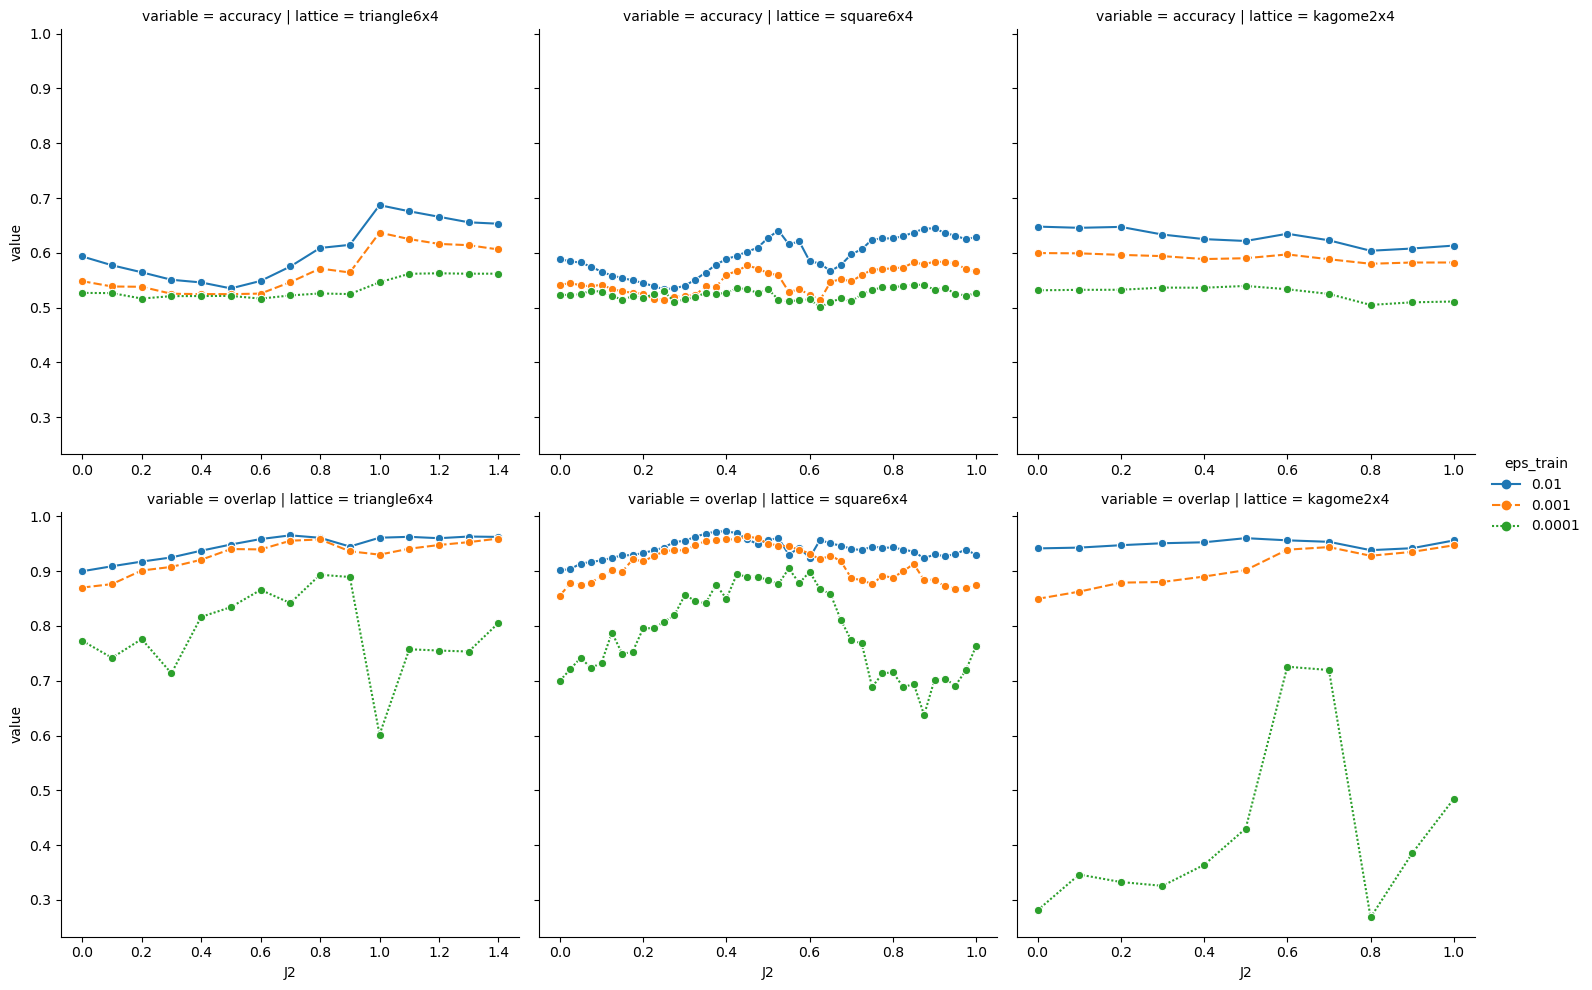

In [16]:
g = sns.relplot(
    df.query("n_spins == 24 and sampling_power_train == 2 and keep_terms == 2 ** 13").melt(
        id_vars=["J2", "lattice", "eps_train", "keep_terms", "sampling_power_train"],
        value_vars=["accuracy", "overlap"],
    ).pipe(column_to(str, "eps_train")),
    x="J2",
    y="value",
    col="lattice",
    hue="eps_train",
    kind="line",
    row="variable",
    style='eps_train',
    markers=['o'],
    facet_kws=dict(sharex=False),
)
g.fig.savefig("fig/fourier_supervised_cleanroom-overlap-accuracy.pdf")

In [25]:
df.assign(log2_keep_terms=np.log2(df["keep_terms"]).astype(int)).query(
        "lattice == 'kagome2x4' and sampling_power_train == 2"
    )['J2'].unique()[3]

0.30000000000000004

In [69]:
(
    df.query('(lattice == "kagome2x4" and J2 == 1)')
    .groupby(["sampling_power_train", "lattice"])[["overlap", "accuracy"]]
    .max()
    .reset_index()
    .melt(id_vars=["sampling_power_train", "lattice"], value_vars=["overlap", "accuracy"])
)

,sampling_power_train,lattice,variable,value
0,0.01,kagome2x4,overlap,0.136493
1,0.50,kagome2x4,overlap,0.959515
2,1.00,kagome2x4,overlap,0.991756
3,2.00,kagome2x4,overlap,0.979280
4,4.00,kagome2x4,overlap,0.955543
5,0.01,kagome2x4,accuracy,0.515420
6,0.50,kagome2x4,accuracy,0.600740
7,1.00,kagome2x4,accuracy,0.644300
8,2.00,kagome2x4,accuracy,0.620040
9,4.00,kagome2x4,accuracy,0.612220


/nix/store/525hx0cz3k0s2nya7r7rai9s4rr5q4kd-python3-3.10.12-env/lib/python3.10/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


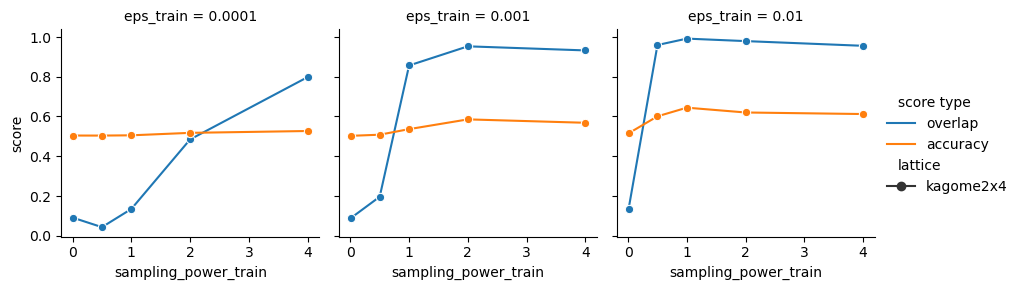

In [73]:
sns.relplot(
    (
        df.query('(lattice == "kagome2x4" and J2 == 1)')
        .groupby(["sampling_power_train", "lattice", "eps_train"])[["overlap", "accuracy"]]
        .max()
        .reset_index()
        .melt(
            id_vars=["sampling_power_train", "lattice", "eps_train"],
            value_vars=["overlap", "accuracy"],
            value_name="score",
            var_name="score type",
        )
    ),
    x="sampling_power_train",
    y="score",
    kind="line",
    markers=["o"],
    col="eps_train",
    hue="score type",
    style="lattice",
    height=2.5,
)
plt.savefig("fig/fourier_supervised_cleanroom-overlap-vs-sampling_power_train.pdf")

/nix/store/525hx0cz3k0s2nya7r7rai9s4rr5q4kd-python3-3.10.12-env/lib/python3.10/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


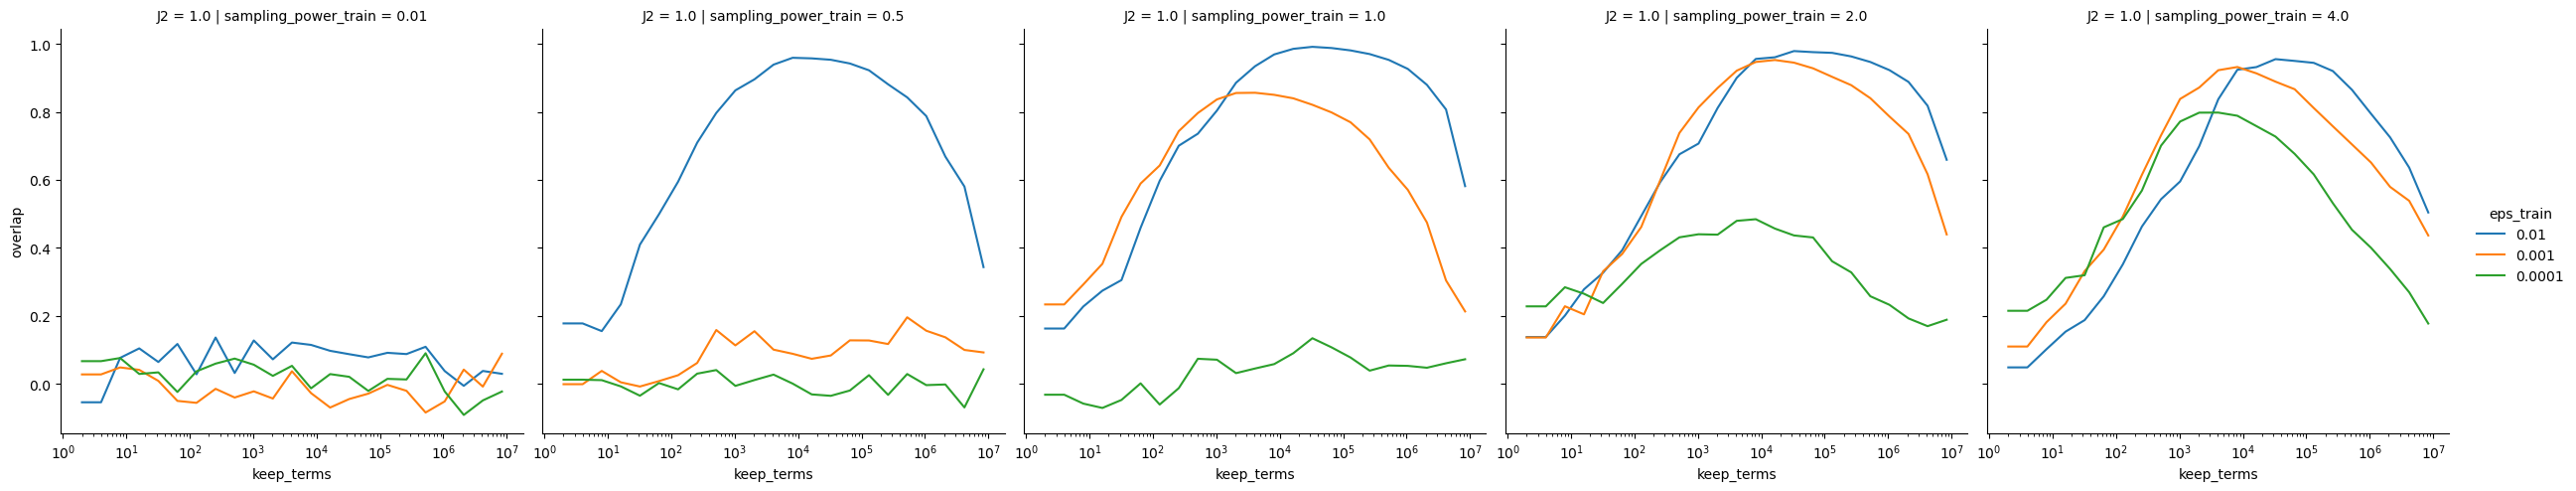

In [40]:
sns.relplot(
    df.assign(log2_keep_terms=np.log2(df["keep_terms"]).astype(int))
    .query(
        'lattice == "kagome2x4" and J2 == 1'
    ).pipe(column_to(str, "eps_train")),
    x="keep_terms",
    y="overlap",
    row="J2",
    col="sampling_power_train",
    hue='eps_train',
    kind="line",
).set(xscale="log")
plt.savefig("fig/fourier_supervised_cleanroom-overlap-v-keep_terms.pdf")

/nix/store/525hx0cz3k0s2nya7r7rai9s4rr5q4kd-python3-3.10.12-env/lib/python3.10/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


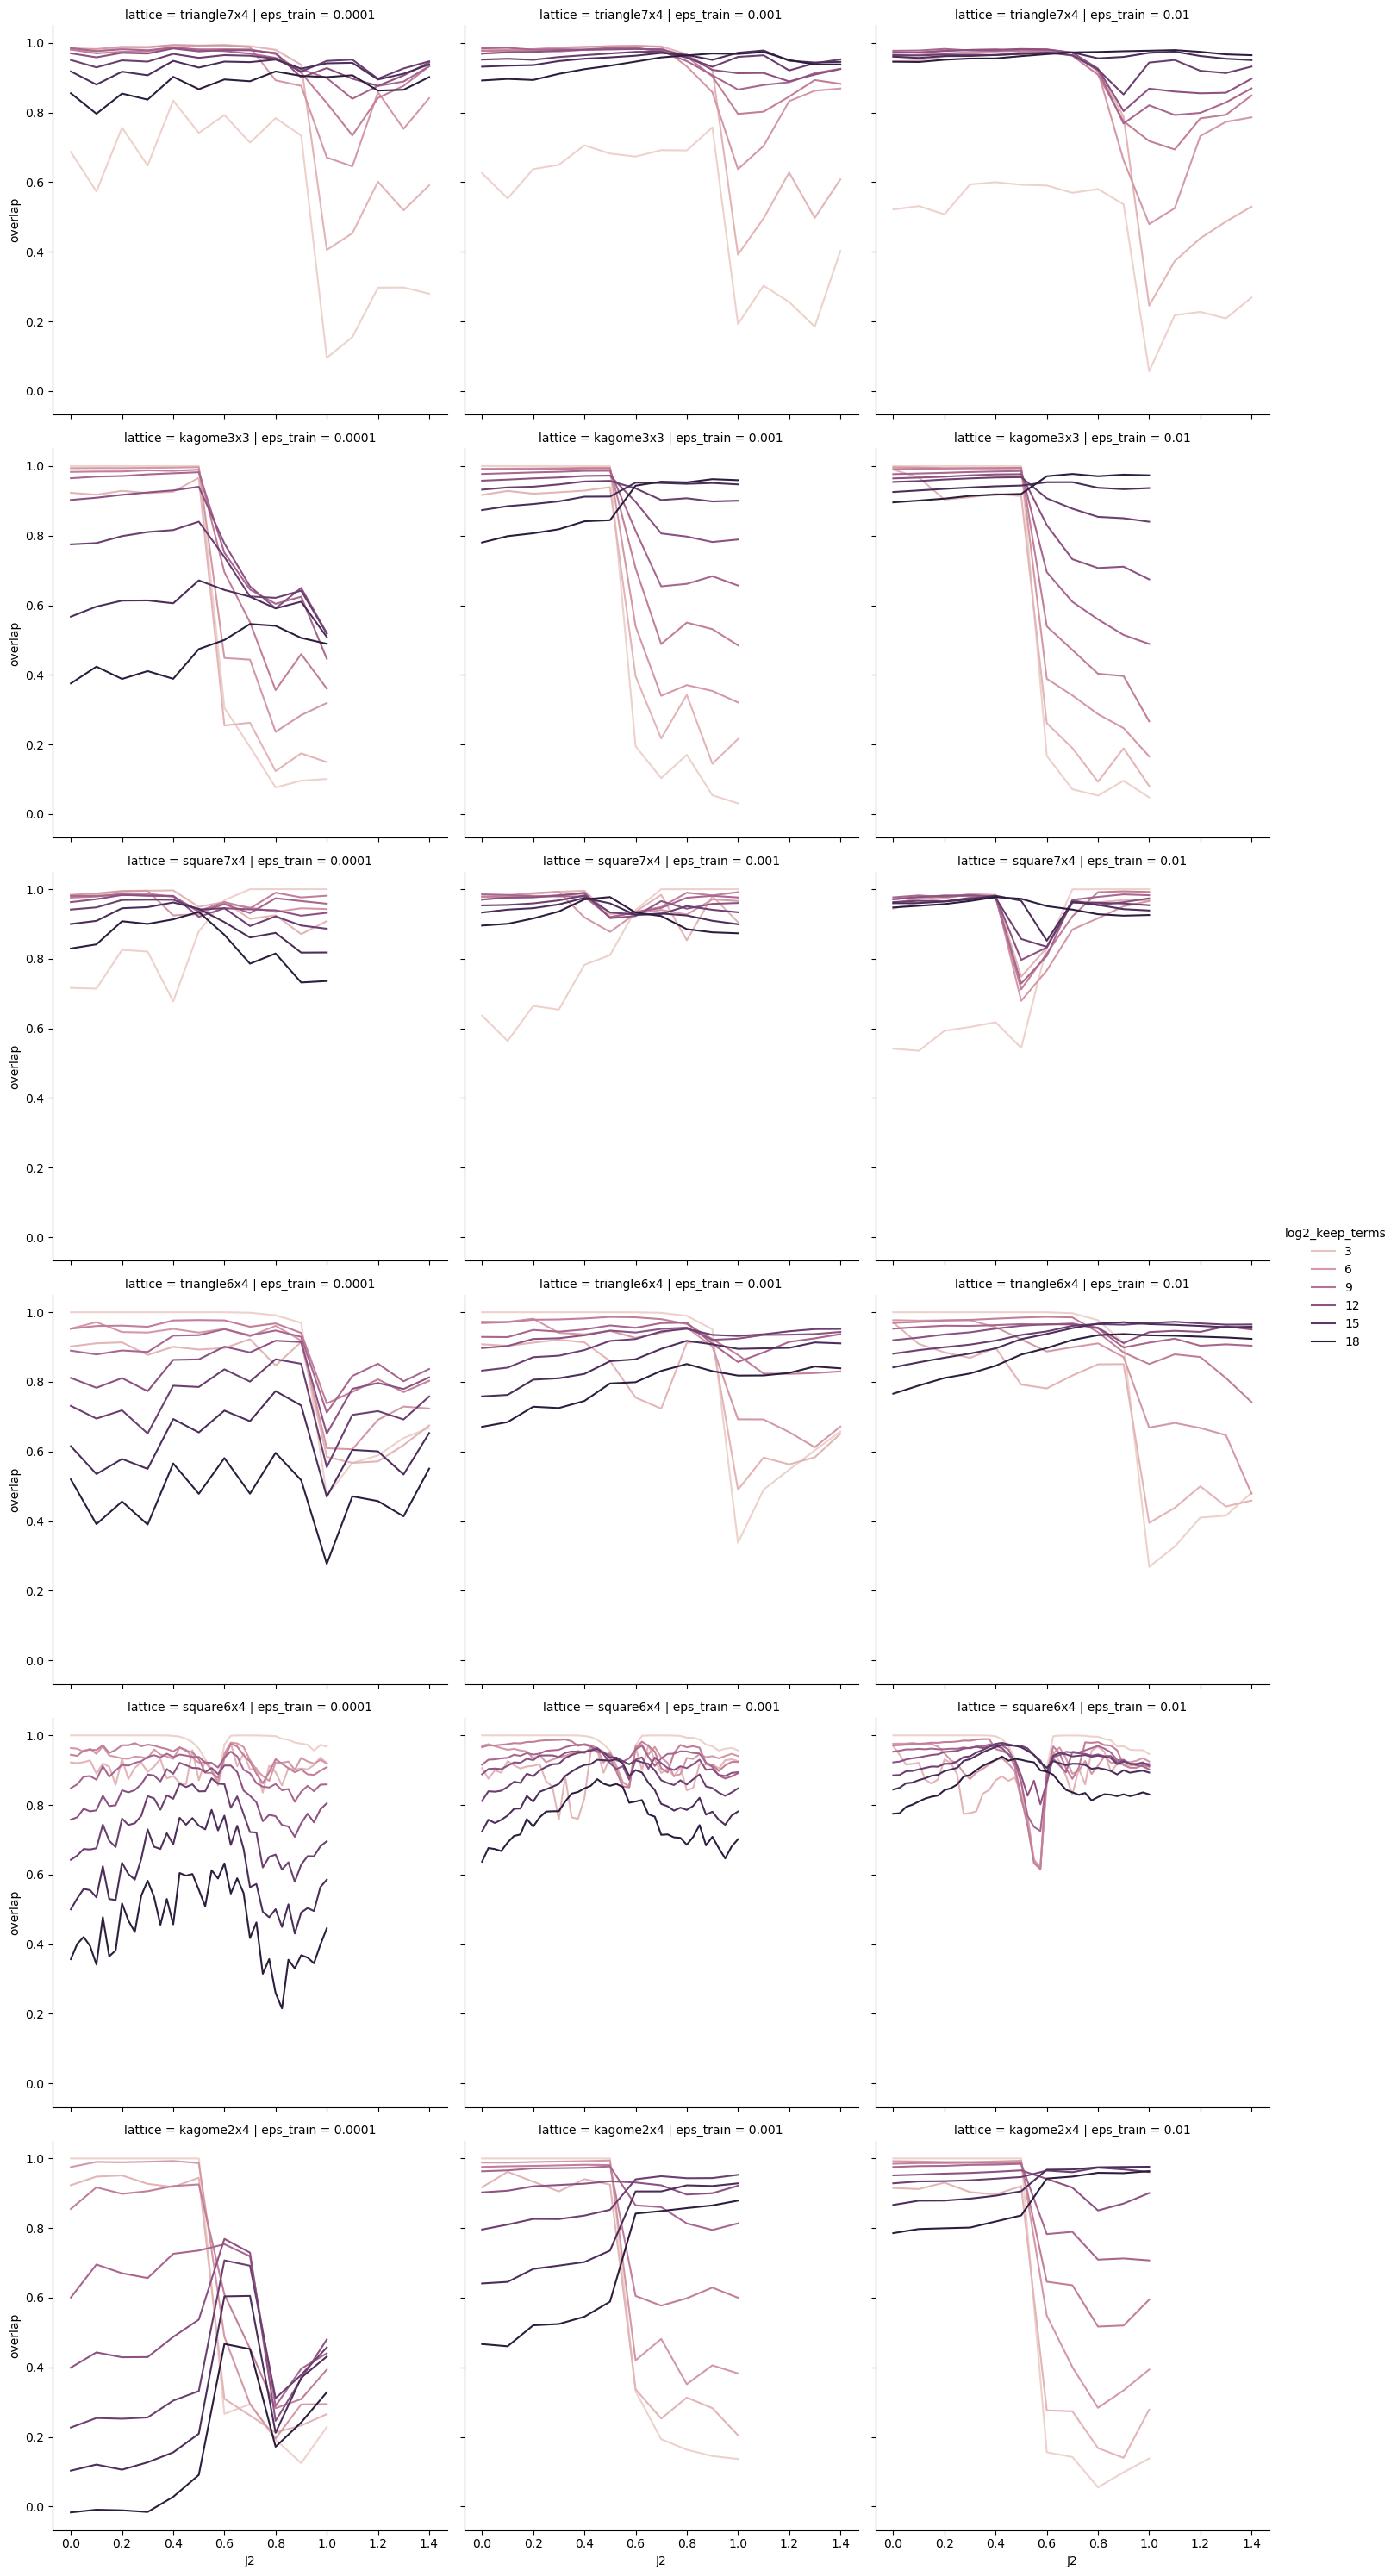

In [8]:
sns.relplot(
    df.assign(log2_keep_terms=np.log2(df["keep_terms"]).astype(int)).query(
        "log2_keep_terms < 20 and log2_keep_terms % 2 == 0 and sampling_power_train == 2"
    ),
    x="J2",
    y="overlap",
    col="eps_train",
    row="lattice",
    hue="log2_keep_terms",
    kind="line",
)

/nix/store/525hx0cz3k0s2nya7r7rai9s4rr5q4kd-python3-3.10.12-env/lib/python3.10/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


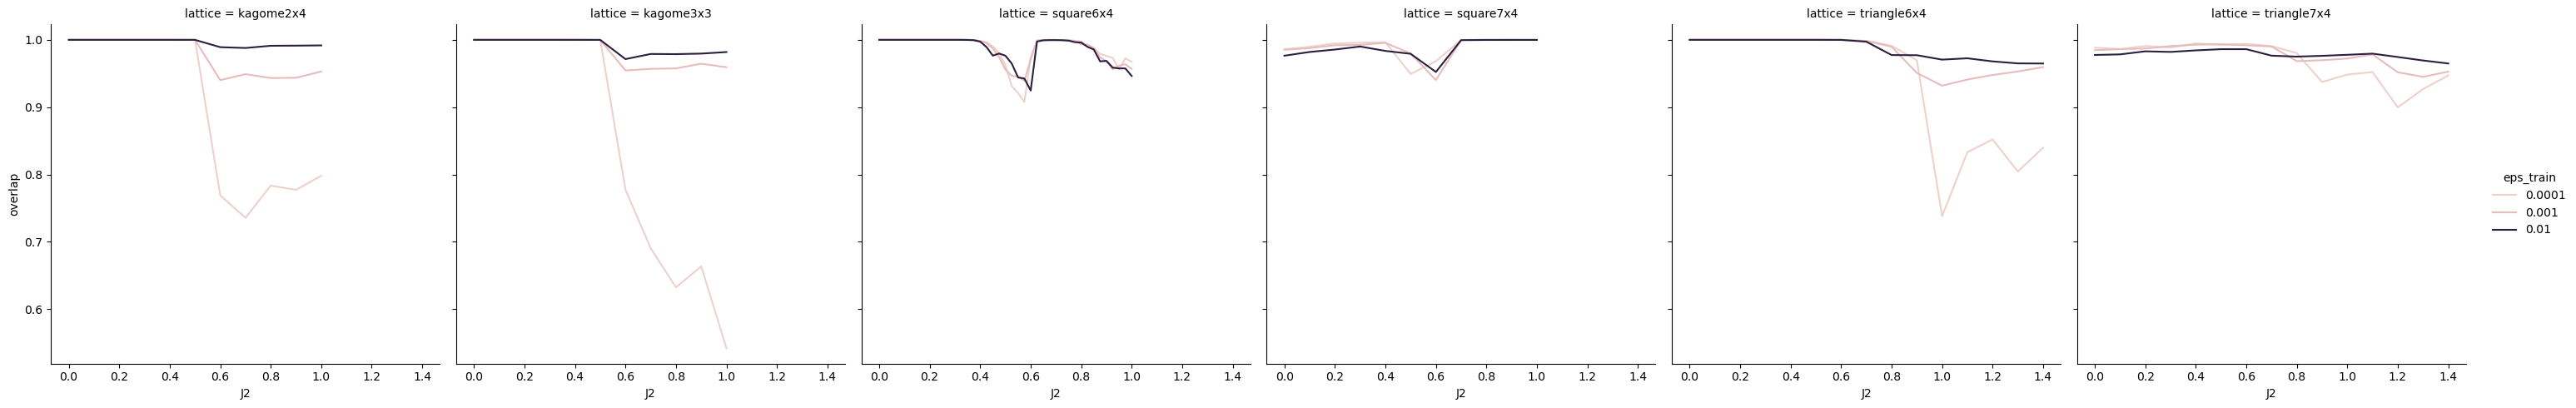

In [6]:
sns.relplot(
    df.groupby(["lattice", "eps_train", "J2"])["overlap"].max().reset_index(),
    x="J2",
    y="overlap",
    hue="eps_train",
    col="lattice",
    kind="line",
)

In [47]:
df.groupby(["lattice", "eps_train", "J2"])["accuracy"].max().reset_index().query(
    'J2 == 1 and lattice.str.startswith("kagome")'
).set_index(["lattice", "eps_train"])['accuracy'].unstack()

eps_train,0.0001,0.0010,0.0100
lattice,,,
kagome2x4,0.51756,0.58534,0.62004
kagome3x3,0.51688,0.61154,0.65642


/nix/store/525hx0cz3k0s2nya7r7rai9s4rr5q4kd-python3-3.10.12-env/lib/python3.10/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


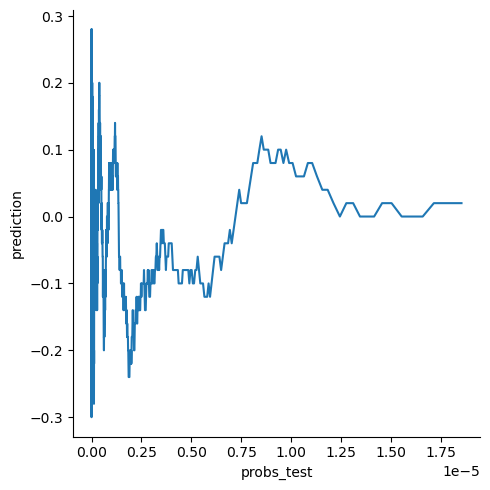

In [16]:
df = pd.DataFrame(
    dict(
        probs_test=probs_test,
        prediction=prediction,
        ground_truth=ground_truth,
        correct=(prediction == ground_truth),
    )
).sort_values('probs_test', ascending=False).reset_index(drop=True)

sns.relplot(df.rolling(window=100).mean(), x='probs_test', y='prediction', kind='line')

In [129]:
eps_train = 0.01

n_samples = int(system.basis.number_states * eps_train)
n_samples_test = 10000
train_set_repr = np.random.choice(
    (system.basis.states), size=n_samples, replace=False, p=probs
)

In [130]:
np.sort(train_set_repr)

array([   61047,    61341,    95975, ..., 16681282, 16681352, 16683270],
      dtype=uint64)

In [131]:
states = system.canonical_basis.states
train_states = states[np.isin(system.basis.state_info(states)[0], train_set_repr)]

In [132]:
assert set(system.basis.state_info(train_states)[0]) == set(train_set_repr)

In [133]:
test_states = np.random.choice(
    states[~np.isin(states, train_states)], size=n_samples_test, replace=True
)
# true_test_signs = np.sign(system.get_ground_state_coeffs(test_states))
true_test_amplitudes = np.abs(system.get_ground_state_coeffs(test_states))

In [157]:
amplitude_binarizer(system, bit=1)(train_states).mean()

-0.31511408601752894

In [158]:
assert (
    set(system.basis.state_info(test_states)[0]) & set(system.basis.state_info(train_states)[0])
    == set()
)

In [159]:
def get_signal(system, transformation_function, states):
    signal = np.zeros(2 ** system.number_spins, dtype=np.float64)
    signal[states] = transformation_function(states)
    return signal

In [160]:
def sign_signal(system):
    def wrapper(states):
        return np.sign(system.get_ground_state_coeffs(states))
    return wrapper

In [177]:
keep_terms = 10000
signal_function = amplitude_binarizer(system, bit=1)
# signal_function = sign_signal(system)
# signal = system.get_ground_state_in_full_basis().astype(np.float64)
# signal_train = np.zeros_like(signal)
signal_train = get_signal(system, signal_function, train_states)
true_test_signs = signal_function(test_states)

signal_train = torch.from_numpy(signal_train)
signal_train = hadamard_transform_pytorch_inplace(signal_train).numpy()
signal_train = keep_largest_n_inplace(signal_train, keep_terms)
signal_train = hadamard_transform_pytorch_inplace(torch.from_numpy(signal_train)).numpy()

In [178]:
predicted_test_signs = np.sign(signal_train[test_states])
sign_overlap = (true_test_signs * predicted_test_signs * true_test_amplitudes ** 2).sum() / np.sum(
    true_test_amplitudes ** 2
)

In [179]:
sign_overlap

0.4113196242703932

In [180]:
(true_test_signs == predicted_test_signs).mean()

0.5568